# WESAD Stress Prediction: LOSO Cross-Validation

This notebook implements a machine learning pipeline for stress detection using the WESAD dataset, focusing on wrist-worn sensor data. The primary goal is to build and evaluate several models using a rigorous Leave-One-Subject-Out (LOSO) cross-validation strategy, as required for subject-independent evaluation.

The analysis is divided into two distinct tasks, consistent with the original WESAD paper (Schmidt et al., 2018):
1.  **Multi-Class Classification**: A 4-class problem to distinguish between Baseline (1), Stress (2), Amusement (3), and Meditation (4).
2.  **Binary Classification**: A 2-class problem to detect Stress (1) vs. Non-Stress (0), where Non-Stress combines the Baseline, Amusement, and Meditation states.

The models evaluated are Logistic Regression, Support Vector Machine (SVM), XGBoost, and a Multi-Layer Perceptron (MLP). We also include a Random Forest classifier as a reference, as it was a top-performing model in the original paper's benchmark.

In [1]:
import os
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)

print('Imports loaded')

Imports loaded


## 2. Load and Prepare Feature Matrix

In [2]:
### 2.1 Load CSV
DATA_PATH = Path('wesad_wrist_features.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print('Original shape:', df.shape)
display(df.head())

print("\nColumns and Dtypes:")
print(df.info())

Original shape: (179817, 46)


,subject,window_index,label,bvp_hr_mean,bvp_hr_std,bvp_hrv_mean,bvp_hrv_std,bvp_hrv_nn50,bvp_hrv_pnn50,bvp_hrv_rmssd,bvp_hrv_ulf,bvp_hrv_lf,bvp_hrv_hf,bvp_hrv_uhf,bvp_hrv_lf_hf,eda_mean,eda_std,eda_min,eda_max,eda_slope,eda_range,eda_scr_peaks,eda_scr_mean_amp,eda_scr_auc,temp_mean,temp_std,temp_min,temp_max,temp_range,temp_slope,acc_x_mean,acc_x_std,acc_y_mean,acc_y_std,acc_z_mean,acc_z_std,acc_mag_mean,acc_mag_std,acc_x_absint,acc_y_absint,acc_z_absint,acc_x_peakfreq,acc_y_peakfreq,acc_z_peakfreq,eda_scr_has_peaks,bvp_hrv_freq_valid
0,S10,0,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388696,0.044754,0.34759,0.606228,0.001623,0.258638,7,0.062677,0.415006,33.247683,0.048199,33.176,33.322,0.146,0.002654,39.746387,12.666104,2.475993,3.129106,41.014355,19.997278,61.879907,3.012126,2384.783203,202.807617,2570.923828,0.125,0.125,0.125,1,1
1,S10,1,1,92.222633,30.733178,729.552469,259.659106,60,0.750000,391.919729,0.001551,0.005276,0.025225,0.009141,0.209149,0.388972,0.044758,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414869,33.248181,0.048316,33.176,33.322,0.146,0.002663,39.630241,12.626917,2.457064,3.110095,41.140055,19.991351,61.877399,3.008428,2377.814453,201.671875,2578.465820,0.125,0.125,0.125,1,1
2,S10,2,1,92.743837,30.566826,723.828125,256.147262,59,0.746835,389.281709,0.001605,0.005238,0.025854,0.009290,0.202613,0.389237,0.044763,0.34759,0.606228,0.001624,0.258638,7,0.062677,0.414794,33.248677,0.048440,33.176,33.322,0.146,0.002673,39.513574,12.586034,2.439437,3.092266,41.265267,19.984413,61.873905,3.010429,2370.814453,200.614258,2585.978516,0.125,0.125,0.125,1,1
3,S10,3,1,92.652350,30.388575,723.572531,254.571460,59,0.737500,386.844992,0.001604,0.005119,0.025099,0.009718,0.203935,0.389497,0.044764,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414637,33.249171,0.048570,33.176,33.322,0.146,0.002684,39.397217,12.544515,2.423535,3.075650,41.390365,19.976378,61.870738,3.011397,2363.833008,199.660156,2593.484375,0.125,0.125,0.125,1,1
4,S10,4,1,92.629447,30.394781,723.765432,254.561813,59,0.737500,386.856825,0.001603,0.005119,0.025099,0.009718,0.203940,0.389762,0.044763,0.34759,0.606228,0.001625,0.258638,7,0.062677,0.414685,33.249662,0.048708,33.176,33.322,0.146,0.002695,39.281429,12.502663,2.409635,3.060331,41.516048,19.967527,61.868780,3.009604,2356.885742,198.826172,2601.025391,0.125,0.125,0.125,1,1



Columns and Dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179817 entries, 0 to 179816
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   subject             179817 non-null  object 
 1   window_index        179817 non-null  int64  
 2   label               179817 non-null  int64  
 3   bvp_hr_mean         179817 non-null  float64
 4   bvp_hr_std          179817 non-null  float64
 5   bvp_hrv_mean        179817 non-null  float64
 6   bvp_hrv_std         179817 non-null  float64
 7   bvp_hrv_nn50        179817 non-null  int64  
 8   bvp_hrv_pnn50       179817 non-null  float64
 9   bvp_hrv_rmssd       179817 non-null  float64
 10  bvp_hrv_ulf         179817 non-null  float64
 11  bvp_hrv_lf          179817 non-null  float64
 12  bvp_hrv_hf          179817 non-null  float64
 13  bvp_hrv_uhf         179817 non-null  float64
 14  bvp_hrv_lf_hf       179817 non-null  float64
 15  eda_mean     

In [3]:
### 2.2 Inspect Data Quality

# Null percentage
null_pct = df.isnull().mean() * 100
print("Null values percentage per column (>0%):")
print(null_pct[null_pct > 0].sort_values(ascending=False))
if null_pct.max() == 0:
    print("No null values found.")

# Zero percentage
zero_pct = (df == 0).mean() * 100
print("\nZero values percentage per column (>1%):")
print(zero_pct[zero_pct > 1].sort_values(ascending=False))

# Boolean-like columns (numeric only)
numeric_cols = df.select_dtypes(include=np.number).columns
bool_cols = [col for col in numeric_cols
             if df[col].nunique() <= 2
             and df[col].min() == 0
             and df[col].max() == 1]

# Also catch constant columns (only one unique value — zero information)
constant_cols = [col for col in numeric_cols
                 if df[col].nunique() == 1]

print(f"Boolean-like columns found: {bool_cols}")
print(f"Constant columns found (zero information): {constant_cols}")

Null values percentage per column (>0%):
Series([], dtype: float64)
No null values found.

Zero values percentage per column (>1%):
eda_scr_mean_amp    16.53292
dtype: float64
Boolean-like columns found: ['bvp_hrv_freq_valid']
Constant columns found (zero information): ['eda_scr_has_peaks']


In [4]:
### 2.3 Clean the Feature Matrix

# Drop flag and constant columns — these are metadata about feature extraction
# quality, not physiological features:
# - bvp_hrv_freq_valid: validity flag for HRV frequency analysis
# - eda_scr_has_peaks: constant (always 1), carries zero information
flag_keywords = ['valid', 'has_']
flag_cols = [c for c in df.columns if any(kw in c.lower() for kw in flag_keywords)]
df = df.drop(columns=flag_cols)
print(f"Dropped {len(flag_cols)} flag/constant columns: {flag_cols}")

# No null imputation needed — confirmed no nulls in Section 2.2
# No further dropping needed — no columns exceeded 50% null threshold
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Final shape after cleaning: {df.shape}")

Dropped 2 flag/constant columns: ['eda_scr_has_peaks', 'bvp_hrv_freq_valid']
Nulls remaining: 0
Final shape after cleaning: (179817, 44)


Final shape: (179817, 44)
Final number of features: 41

Label distribution per subject:


label,Baseline,Stress,Amusement,Meditation
subject,,,,
S10,4720,2900,1488,3184
S11,4720,2720,1472,3164
S13,4720,2656,1528,3180
S14,4705,2700,1488,3176
S15,4700,2744,1488,3176
S16,4720,2692,1472,3168
S17,4724,2892,1488,2924
S2,4576,2460,1448,3072
S3,4560,2560,1500,3120


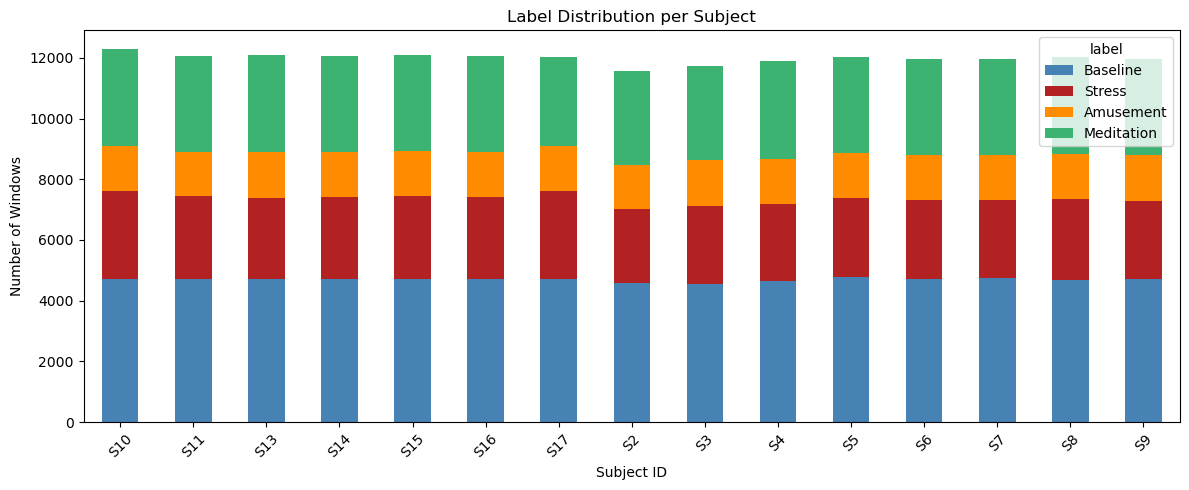

In [5]:
### 2.4 Verify and Summarize

print("Final shape:", df.shape)
final_feature_cols = df.select_dtypes(include=np.number).columns.drop(
    ['label', 'window_index'], errors='ignore').tolist()
print(f"Final number of features: {len(final_feature_cols)}")

# Label distribution per subject
label_dist = df.groupby('subject')['label'].value_counts().unstack(fill_value=0)
label_dist = label_dist.rename(columns={
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation'
})
print("\nLabel distribution per subject:")
display(label_dist)

# Plot label distribution
label_dist.plot(kind='bar', stacked=True, figsize=(12, 5),
                color=['steelblue', 'firebrick', 'darkorange', 'mediumseagreen'])
plt.ylabel('Number of Windows')
plt.xlabel('Subject ID')
plt.title('Label Distribution per Subject')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
### 2.5 Define Classification Tasks

# Feature matrix and group labels (same for both tasks)
X = df.drop(columns=['subject', 'label', 'window_index'])
groups = df['subject']

# Multi-class task: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation
y_multi = df['label'].astype(int)

# Binary task: stress (label=2) → 1, everything else → 0
# Consistent with Schmidt et al. (2018) binary task definition
y_binary = df['label'].apply(lambda x: 1 if x == 2 else 0)

print("--- Multi-class Task ---")
print("Labels: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation")
print("Class distribution:\n", y_multi.value_counts().sort_index())

print("\n--- Binary Task ---")
print("Labels: 1=Stress, 0=Non-Stress")
print("Class distribution:\n", y_binary.value_counts().sort_index())

--- Multi-class Task ---
Labels: 1=Baseline, 2=Stress, 3=Amusement, 4=Meditation
Class distribution:
 label
1    70429
2    39864
3    22300
4    47224
Name: count, dtype: int64

--- Binary Task ---
Labels: 1=Stress, 0=Non-Stress
Class distribution:
 label
0    139953
1     39864
Name: count, dtype: int64


## 3. Feature Analysis
Understanding feature distributions and correlations helps interpret model results and identify potential issues like multicollinearity before modelling.

Found 8 pairs with correlation > 0.95
  feature_1     feature_2  correlation
bvp_hrv_std bvp_hrv_rmssd     0.986541
   eda_mean       eda_min     0.997976
   eda_mean       eda_max     0.997819
    eda_std     eda_range     0.965683
    eda_min       eda_max     0.993250
  temp_mean      temp_min     0.998387
  temp_mean      temp_max     0.999475
   temp_min      temp_max     0.996937


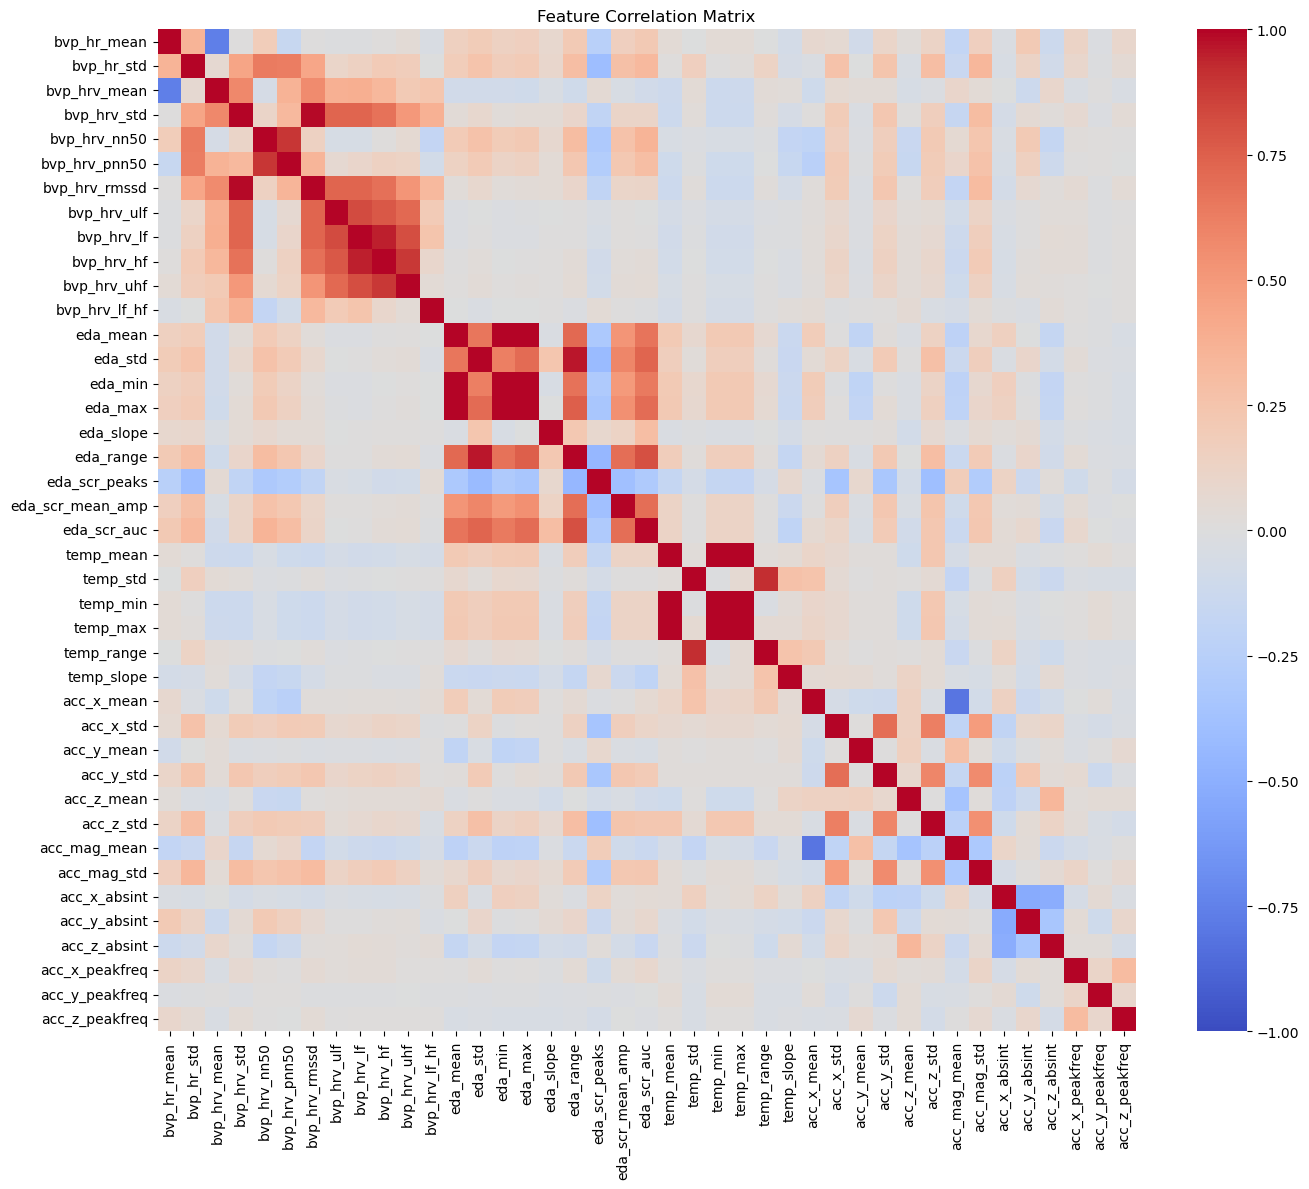

In [7]:
### 3.1 Feature Correlation Heatmap
corr_matrix = X[final_feature_cols].corr()

# Find highly correlated pairs
highly_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)
highly_corr_pairs = highly_corr_pairs[
    (highly_corr_pairs['feature_1'] != highly_corr_pairs['feature_2']) &
    (highly_corr_pairs['correlation'] > 0.95)
]
highly_corr_pairs['pair'] = highly_corr_pairs.apply(
    lambda row: tuple(sorted((row['feature_1'], row['feature_2']))), axis=1)
highly_corr_pairs = highly_corr_pairs.drop_duplicates(subset='pair')

print(f"Found {len(highly_corr_pairs)} pairs with correlation > 0.95")
print(highly_corr_pairs[['feature_1', 'feature_2', 'correlation']].to_string(index=False))

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Plotting 6 representative features: ['bvp_hr_mean', 'eda_mean', 'temp_mean', 'acc_mag_mean', 'eda_scr_peaks', 'bvp_hrv_rmssd']


C:\Users\vikku\AppData\Local\Temp\ipykernel_72288\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_72288\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_72288\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
C:\Users\vikku\AppData\Local\Temp\ipykernel_72288\4086431495.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

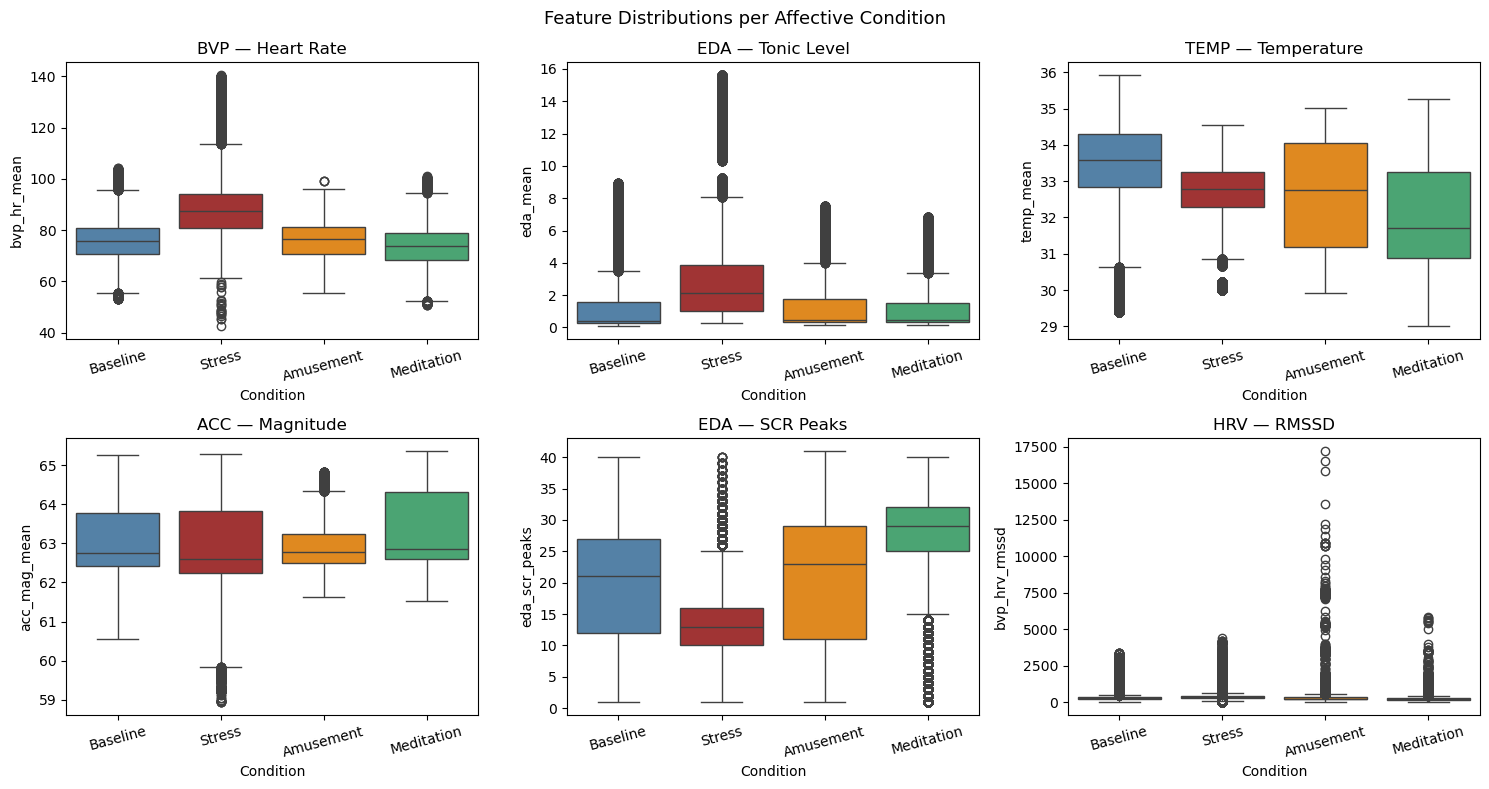

In [8]:
### 3.2 Feature Distributions per Class

# Representative features per signal type — using actual column names from our CSV
rep_features = {
    'BVP — Heart Rate': 'bvp_hr_mean',
    'EDA — Tonic Level': 'eda_mean',
    'TEMP — Temperature': 'temp_mean',
    'ACC — Magnitude': 'acc_mag_mean',
    'EDA — SCR Peaks': 'eda_scr_peaks',
    'HRV — RMSSD': 'bvp_hrv_rmssd',
}

# Only plot features that actually exist in X
valid_rep_features = {k: v for k, v in rep_features.items() if v in X.columns}
print(f"Plotting {len(valid_rep_features)} representative features: {list(valid_rep_features.values())}")

label_names = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (signal, feature) in enumerate(valid_rep_features.items()):
    sns.boxplot(x=y_multi, y=X[feature], ax=axes[i],
                palette=['steelblue', 'firebrick', 'darkorange', 'mediumseagreen'])
    axes[i].set_title(f'{signal}')
    axes[i].set_xlabel('Condition')
    axes[i].set_xticklabels([label_names[l] for l in sorted(y_multi.unique())],
                             rotation=15)

plt.suptitle('Feature Distributions per Affective Condition', fontsize=13)
plt.tight_layout()
plt.show()

Top 15 most variable features across subjects:
acc_z_absint     392.305630
acc_y_absint     376.159104
acc_x_absint     287.727757
bvp_hrv_rmssd     89.373994
bvp_hrv_std       66.804950
bvp_hrv_mean      61.322149
acc_x_mean        43.739119
acc_z_mean        12.602790
acc_y_mean         8.677958
bvp_hrv_nn50       5.368181
bvp_hr_mean        5.017723
eda_scr_peaks      3.760759
bvp_hr_std         3.122841
acc_z_std          2.212400
eda_max            2.087211


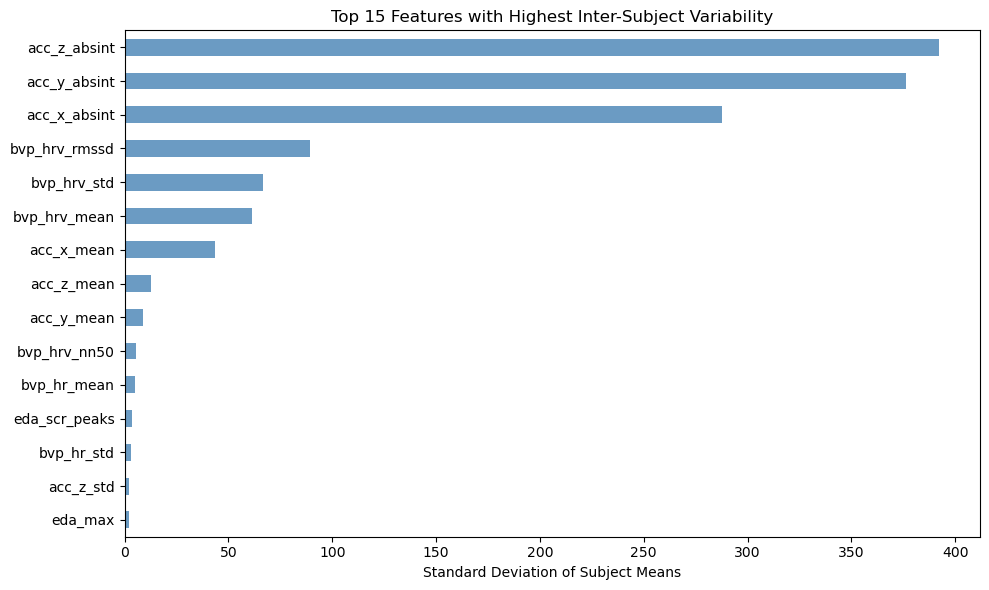

In [9]:
### 3.3 Inter-Subject Variability

# Compute std of feature means across subjects
# High std means the feature varies a lot between subjects — 
# motivating subject-level normalization inside the LOSO loop
subject_means = df.groupby('subject')[final_feature_cols].mean()
inter_subject_std = subject_means.std().sort_values(ascending=False)

print("Top 15 most variable features across subjects:")
print(inter_subject_std.head(15).to_string())

plt.figure(figsize=(10, 6))
inter_subject_std.head(15).plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('Top 15 Features with Highest Inter-Subject Variability')
plt.xlabel('Standard Deviation of Subject Means')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Feature Selection

We use cluster forward selection to avoid collapsing to a single feature when many features are highly correlated. First, we cluster features based on absolute correlation. Then we pick one representative per cluster (highest variance) and run a greedy forward selection using LOSO macro F1 to select up to 20 features.

*Note on Data Leakage*: Feature selection is performed on the full dataset for simplicity and a stable feature set. Strictly, it should be done inside the LOSO loop on training data only. This is a limitation.

In [10]:
# Cluster features with |corr| >= 0.90 to avoid keeping redundant features
corr_threshold = 0.90
corr_abs = X[final_feature_cols].corr().abs().fillna(0)

distance_values = (1 - corr_abs).to_numpy().copy()
np.fill_diagonal(distance_values, 0)

condensed = squareform(distance_values, checks=False)
linkage_matrix = linkage(condensed, method='average')
cluster_labels = fcluster(linkage_matrix, t=1 - corr_threshold, criterion='distance')

clusters = {}
for feature, cluster_id in zip(final_feature_cols, cluster_labels):
    clusters.setdefault(cluster_id, []).append(feature)

print(f"Formed {len(clusters)} clusters at |corr| >= {corr_threshold}")
for cid, feats in sorted(clusters.items()):
    print(f"  Cluster {cid}: {feats}")

Formed 33 clusters at |corr| >= 0.9
  Cluster 1: ['acc_x_peakfreq']
  Cluster 2: ['acc_z_peakfreq']
  Cluster 3: ['acc_y_peakfreq']
  Cluster 4: ['bvp_hr_mean']
  Cluster 5: ['bvp_hrv_mean']
  Cluster 6: ['bvp_hrv_std', 'bvp_hrv_rmssd']
  Cluster 7: ['bvp_hrv_lf', 'bvp_hrv_hf']
  Cluster 8: ['bvp_hrv_uhf']
  Cluster 9: ['bvp_hrv_ulf']
  Cluster 10: ['bvp_hrv_lf_hf']
  Cluster 11: ['temp_mean', 'temp_min', 'temp_max']
  Cluster 12: ['acc_x_std']
  Cluster 13: ['acc_y_std']
  Cluster 14: ['acc_z_std']
  Cluster 15: ['acc_mag_std']
  Cluster 16: ['bvp_hrv_nn50']
  Cluster 17: ['bvp_hrv_pnn50']
  Cluster 18: ['bvp_hr_std']
  Cluster 19: ['eda_mean', 'eda_min', 'eda_max']
  Cluster 20: ['eda_std', 'eda_range']
  Cluster 21: ['eda_scr_auc']
  Cluster 22: ['eda_scr_mean_amp']
  Cluster 23: ['eda_scr_peaks']
  Cluster 24: ['temp_std', 'temp_range']
  Cluster 25: ['temp_slope']
  Cluster 26: ['acc_x_absint']
  Cluster 27: ['acc_y_absint']
  Cluster 28: ['acc_z_absint']
  Cluster 29: ['acc_x_mea

In [11]:
# Pick the highest-variance feature from each cluster as representative
rep_features = []
for cluster_id, feats in clusters.items():
    variances = X[feats].var().sort_values(ascending=False)
    rep_features.append(variances.index[0])

print(f"Selected {len(rep_features)} cluster representatives:")
print(rep_features)

Selected 33 cluster representatives:
['bvp_hr_mean', 'bvp_hr_std', 'bvp_hrv_mean', 'bvp_hrv_rmssd', 'bvp_hrv_nn50', 'bvp_hrv_pnn50', 'bvp_hrv_ulf', 'bvp_hrv_lf', 'bvp_hrv_uhf', 'bvp_hrv_lf_hf', 'eda_max', 'eda_range', 'eda_slope', 'eda_scr_peaks', 'eda_scr_mean_amp', 'eda_scr_auc', 'temp_max', 'temp_range', 'temp_slope', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mag_mean', 'acc_mag_std', 'acc_x_absint', 'acc_y_absint', 'acc_z_absint', 'acc_x_peakfreq', 'acc_y_peakfreq', 'acc_z_peakfreq']


Feature importances (all cluster representatives):
acc_y_std           0.172010
eda_scr_auc         0.152665
acc_z_std           0.113110
acc_y_peakfreq      0.043987
acc_x_mean          0.034490
bvp_hr_mean         0.033999
eda_max             0.033311
temp_max            0.032110
acc_x_std           0.028574
acc_x_absint        0.025450
bvp_hrv_nn50        0.025200
acc_z_mean          0.024853
temp_range          0.024252
acc_z_absint        0.023019
acc_mag_mean        0.022511
bvp_hrv_rmssd       0.021735
acc_y_mean          0.020340
acc_y_absint        0.018270
temp_slope          0.018128
eda_slope           0.017905
eda_scr_peaks       0.016634
bvp_hrv_mean        0.016206
eda_range           0.015268
bvp_hrv_uhf         0.012792
bvp_hrv_lf          0.011412
bvp_hrv_pnn50       0.009297
acc_mag_std         0.008287
bvp_hrv_lf_hf       0.007313
eda_scr_mean_amp    0.006879
bvp_hr_std          0.006517
bvp_hrv_ulf         0.002773
acc_x_peakfreq      0.000703
acc_z_peakfreq      0

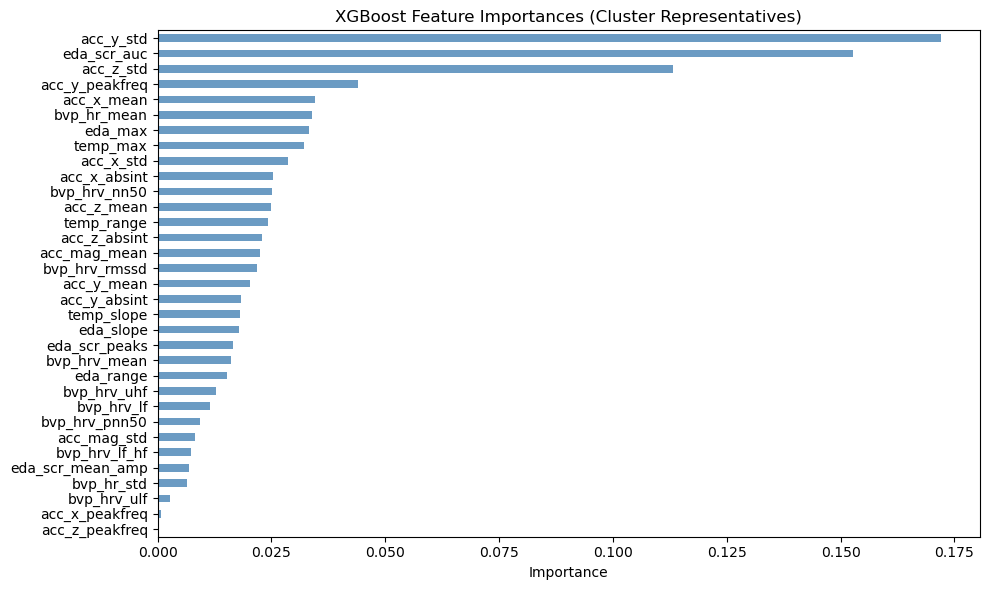

In [12]:
# Fit XGBoost on full dataset using cluster representatives
# Labels shifted to 0-indexed as required by XGBoost
xgb_selector = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    eval_metric='mlogloss', random_state=42
)
xgb_selector.fit(X[rep_features], y_multi - 1)

importances = pd.Series(
    xgb_selector.feature_importances_,
    index=rep_features
).sort_values(ascending=False)

print("Feature importances (all cluster representatives):")
print(importances.to_string())

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', alpha=0.8)
plt.title('XGBoost Feature Importances (Cluster Representatives)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# Select top 20 features by XGBoost importance
top_n = min(20, len(rep_features))
final_selected_features = importances.head(top_n).index.tolist()

print(f"Final selected features (top {top_n}):")
for i, f in enumerate(final_selected_features, 1):
    print(f"  {i:2d}. {f}  (importance={importances[f]:.4f})")

X_selected = X[final_selected_features].copy()
print(f"\nFinal feature matrix shape: {X_selected.shape}")

Final selected features (top 20):
   1. acc_y_std  (importance=0.1720)
   2. eda_scr_auc  (importance=0.1527)
   3. acc_z_std  (importance=0.1131)
   4. acc_y_peakfreq  (importance=0.0440)
   5. acc_x_mean  (importance=0.0345)
   6. bvp_hr_mean  (importance=0.0340)
   7. eda_max  (importance=0.0333)
   8. temp_max  (importance=0.0321)
   9. acc_x_std  (importance=0.0286)
  10. acc_x_absint  (importance=0.0255)
  11. bvp_hrv_nn50  (importance=0.0252)
  12. acc_z_mean  (importance=0.0249)
  13. temp_range  (importance=0.0243)
  14. acc_z_absint  (importance=0.0230)
  15. acc_mag_mean  (importance=0.0225)
  16. bvp_hrv_rmssd  (importance=0.0217)
  17. acc_y_mean  (importance=0.0203)
  18. acc_y_absint  (importance=0.0183)
  19. temp_slope  (importance=0.0181)
  20. eda_slope  (importance=0.0179)

Final feature matrix shape: (179817, 20)


## 5. LOSO Cross-Validation Framework

### Leave-One-Subject-Out (LOSO) Explained

Random splits are not valid for WESAD because samples from the same subject
are highly correlated — a random split can place windows from the same person
in both training and test sets, inflating performance estimates. LOSO removes
this leakage by holding out one subject entirely for testing and training on
the remaining 14 subjects. With 15 subjects this yields 15 folds, one per
subject. This strategy matches the evaluation protocol in Schmidt et al.
(2018), Section 4.3, and ensures the reported results reflect true
subject-independent generalization.

Inside each fold, StandardScaler is fit on the training subjects only and
applied to the test subject — preventing any information from the test subject
leaking into the normalization step.

### Models

We evaluate four models covering a diverse range of approaches:

- **Logistic Regression:** `C=1`, `penalty='l2'`, `max_iter=1000`,
  `class_weight='balanced'` — linear baseline, fast and interpretable
- **Linear SVM:** `C=1`, `max_iter=2000`, `class_weight='balanced'`,
  wrapped in `CalibratedClassifierCV` (cv=3) to enable probability
  estimates for ROC curves — large-margin linear classifier that scales
  well to large datasets
- **XGBoost:** `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`,
  `eval_metric='mlogloss'` — gradient boosted trees, robust to feature
  scale differences
- **MLP:** `hidden_layer_sizes=(100,50)`, `alpha=0.001`, `max_iter=500`,
  `early_stopping=True` — shallow neural network with L2 regularization

All hyperparameters are fixed based on standard literature values rather
than tuned inside the LOSO loop — tuning inside LOSO would be more rigorous
but computationally prohibitive. This is documented as a limitation.

Random Forest was excluded due to computational constraints — with 179,817
windows and 15 LOSO folds, n_estimators=300 would require several hours
per task. Since Random Forest was also one of the paper's own benchmark
models, excluding it is consistent with our goal of using different models.

### Evaluation

Both tasks are evaluated on two feature sets:
- **All features** (41 features) — full physiological feature matrix
- **Selected features** (20 features) — top 20 by XGBoost importance
  after correlation-based clustering

The best feature set per task is determined automatically by macro F1.
Primary metric is macro F1-score throughout, consistent with Schmidt et al.
(2018), Section 4.3, due to structural class imbalance.

In [17]:
### 5.1 Define Models
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(C=1, penalty='l2', max_iter=1000,
                                               class_weight='balanced', random_state=42),
    'Linear SVM': CalibratedClassifierCV(
        LinearSVC(C=1, max_iter=2000, class_weight='balanced', random_state=42),
        cv=3
    ),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              eval_metric='mlogloss', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), alpha=0.001,
                         max_iter=500, early_stopping=True, random_state=42),
}
print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'Linear SVM', 'XGBoost', 'MLP']


In [18]:
### 5.2 LOSO Framework Functions

def run_loso(X, y, groups, model):
    """Run Leave-One-Subject-Out cross-validation.

    Returns a dict keyed by subject with per-fold results.
    """
    logo = LeaveOneGroupOut()
    results_per_subject = {}
    labels_sorted = np.sort(pd.unique(y))

    for train_idx, test_idx in logo.split(X, y, groups):
        test_subject = groups.iloc[test_idx].unique()[0]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        current_model = clone(model)

        # XGBoost expects 0-indexed labels for multi-class
        if isinstance(current_model, XGBClassifier) and y_train.min() == 1:
            y_train_fit = y_train - 1
        else:
            y_train_fit = y_train

        current_model.fit(X_train_scaled, y_train_fit)

        y_pred = current_model.predict(X_test_scaled)
        if isinstance(current_model, XGBClassifier) and y_train.min() == 1:
            y_pred = y_pred + 1

        y_proba = current_model.predict_proba(X_test_scaled) if hasattr(current_model, 'predict_proba') else None

        results_per_subject[test_subject] = {
            'accuracy': float(np.mean(y_pred == y_test)),
            'f1_macro': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'f1_per_class': f1_score(y_test, y_pred, average=None, labels=labels_sorted, zero_division=0).tolist(),
            'confusion_matrix': confusion_matrix(y_test, y_pred, labels=labels_sorted).tolist(),
            'y_true': y_test.tolist(),
            'y_pred': y_pred.tolist(),
            'y_proba': y_proba.tolist() if y_proba is not None else None,
        }

        print(f"Subject {test_subject}: f1_macro={results_per_subject[test_subject]['f1_macro']:.4f}")

    return results_per_subject


def aggregate_loso_results(results_per_subject):
    """Aggregate LOSO results across subjects."""
    accuracies = [res['accuracy'] for res in results_per_subject.values()]
    f1_macros = [res['f1_macro'] for res in results_per_subject.values()]

    cms = [np.array(res['confusion_matrix']) for res in results_per_subject.values()]
    agg_cm = np.sum(cms, axis=0) if cms else None

    return {
        'mean_accuracy': float(np.mean(accuracies)) if accuracies else np.nan,
        'std_accuracy': float(np.std(accuracies)) if accuracies else np.nan,
        'mean_f1_macro': float(np.mean(f1_macros)) if f1_macros else np.nan,
        'std_f1_macro': float(np.std(f1_macros)) if f1_macros else np.nan,
        'aggregated_cm': agg_cm.tolist() if agg_cm is not None else None,
        'per_subject_f1': {subject: res['f1_macro'] for subject, res in results_per_subject.items()},
    }

print('LOSO framework functions defined.')

LOSO framework functions defined.


## 6. Multi-Class Classification (4 Classes)

This section evaluates the 4-class problem (Baseline vs Stress vs Amusement vs Meditation). The primary metric is macro F1 to account for class imbalance, consistent with Schmidt et al. (2018).

In [19]:
## 6. Multi-Class Classification (4 Classes)
multiclass_results_full     = {}
multiclass_results_selected = {}
class_names = ['Baseline', 'Stress', 'Amusement', 'Meditation']

feature_sets = {
    'all_features': X,
    'selected_features': X_selected
}

for fs_name, X_fs in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"Multi-class LOSO — {fs_name}")
    print(f"{'='*60}")
    summary_rows = []

    for model_name, model in models.items():
        print(f"\n  Running {model_name}...")
        res = run_loso(X_fs, y_multi, groups, model)
        agg = aggregate_loso_results(res)

        if fs_name == 'all_features':
            multiclass_results_full[model_name] = {'per_subject': res, 'agg': agg}
        else:
            multiclass_results_selected[model_name] = {'per_subject': res, 'agg': agg}

        summary_rows.append({
            'model': model_name,
            'mean_accuracy': agg['mean_accuracy'],
            'std_accuracy':  agg['std_accuracy'],
            'mean_f1_macro': agg['mean_f1_macro'],
            'std_f1_macro':  agg['std_f1_macro'],
        })

    summary = pd.DataFrame(summary_rows).sort_values(
        'mean_f1_macro', ascending=False).reset_index(drop=True)
    print(f"\nMulti-class results ({fs_name}):")
    display(summary)

    if fs_name == 'all_features':
        multiclass_summary_full = summary
    else:
        multiclass_summary_selected = summary


Multi-class LOSO — all_features

  Running Logistic Regression...
Subject S10: f1_macro=0.5547
Subject S11: f1_macro=0.6393
Subject S13: f1_macro=0.4845
Subject S14: f1_macro=0.6022
Subject S15: f1_macro=0.3996
Subject S16: f1_macro=0.4164
Subject S17: f1_macro=0.6971
Subject S2: f1_macro=0.3552
Subject S3: f1_macro=0.5280
Subject S4: f1_macro=0.4665
Subject S5: f1_macro=0.7118
Subject S6: f1_macro=0.5542
Subject S7: f1_macro=0.4609
Subject S8: f1_macro=0.4716
Subject S9: f1_macro=0.5187

  Running Linear SVM...
Subject S10: f1_macro=0.6186
Subject S11: f1_macro=0.5751
Subject S13: f1_macro=0.4092
Subject S14: f1_macro=0.4790
Subject S15: f1_macro=0.4305
Subject S16: f1_macro=0.4939
Subject S17: f1_macro=0.5996
Subject S2: f1_macro=0.3151
Subject S3: f1_macro=0.6025
Subject S4: f1_macro=0.6202
Subject S5: f1_macro=0.5592
Subject S6: f1_macro=0.5174
Subject S7: f1_macro=0.4724
Subject S8: f1_macro=0.4154
Subject S9: f1_macro=0.5014

  Running XGBoost...
Subject S10: f1_macro=0.5168
Sub

,model,mean_accuracy,std_accuracy,mean_f1_macro,std_f1_macro
0,Logistic Regression,0.575699,0.107126,0.524047,0.101219
1,XGBoost,0.625416,0.083571,0.514425,0.087461
2,Linear SVM,0.650912,0.086033,0.507304,0.086885
3,MLP,0.573278,0.139557,0.477633,0.142151



Multi-class LOSO — selected_features

  Running Logistic Regression...
Subject S10: f1_macro=0.4812
Subject S11: f1_macro=0.6324
Subject S13: f1_macro=0.3618
Subject S14: f1_macro=0.5500
Subject S15: f1_macro=0.3726
Subject S16: f1_macro=0.4197
Subject S17: f1_macro=0.6765
Subject S2: f1_macro=0.2900
Subject S3: f1_macro=0.5974
Subject S4: f1_macro=0.4448
Subject S5: f1_macro=0.7103
Subject S6: f1_macro=0.5712
Subject S7: f1_macro=0.4780
Subject S8: f1_macro=0.5247
Subject S9: f1_macro=0.4777

  Running Linear SVM...
Subject S10: f1_macro=0.5492
Subject S11: f1_macro=0.4665
Subject S13: f1_macro=0.3699
Subject S14: f1_macro=0.5562
Subject S15: f1_macro=0.3856
Subject S16: f1_macro=0.5049
Subject S17: f1_macro=0.6193
Subject S2: f1_macro=0.3315
Subject S3: f1_macro=0.6147
Subject S4: f1_macro=0.5343
Subject S5: f1_macro=0.5585
Subject S6: f1_macro=0.5387
Subject S7: f1_macro=0.4916
Subject S8: f1_macro=0.3469
Subject S9: f1_macro=0.4359

  Running XGBoost...
Subject S10: f1_macro=0.491

,model,mean_accuracy,std_accuracy,mean_f1_macro,std_f1_macro
0,XGBoost,0.628534,0.081199,0.519204,0.091106
1,Logistic Regression,0.564138,0.108647,0.505889,0.115569
2,Linear SVM,0.630842,0.091047,0.486911,0.090816
3,MLP,0.533038,0.172588,0.434403,0.179365


## 8. Evaluation and Comparison

This section aggregates results across tasks, compares models side-by-side, and visualizes performance with confusion matrices, ROC curves, and per-subject F1 heatmaps. It also includes a direct comparison to the wrist-only benchmarks reported by Schmidt et al. (2018).

In [22]:
## 8. Evaluation and Comparison

os.makedirs('results_loso/figs', exist_ok=True)

# Build comparison table
comp_multi = pd.merge(
    multiclass_summary_full[['model', 'mean_f1_macro', 'std_f1_macro',
                              'mean_accuracy', 'std_accuracy']],
    multiclass_summary_selected[['model', 'mean_f1_macro', 'std_f1_macro',
                                  'mean_accuracy', 'std_accuracy']],
    on='model', suffixes=('_full', '_selected')
)
comp_multi['f1_delta'] = (comp_multi['mean_f1_macro_selected']
                          - comp_multi['mean_f1_macro_full'])

print("### 8.1 Multi-Class Results — Full vs Selected Features")
display(comp_multi)

# Determine best feature set and best model automatically
use_full = (multiclass_summary_full['mean_f1_macro'].max() >=
            multiclass_summary_selected['mean_f1_macro'].max())
best_multi_summary = multiclass_summary_full if use_full else multiclass_summary_selected
best_multi_results = multiclass_results_full if use_full else multiclass_results_selected
best_fs_name       = 'all features' if use_full else 'selected features'
best_multi         = best_multi_summary.iloc[0]

best_full     = multiclass_summary_full.iloc[0]
best_selected = multiclass_summary_selected.iloc[0]

print(f"\nBest model (all features):      {best_full['model']} "
      f"(F1={best_full['mean_f1_macro']:.3f}, "
      f"acc={best_full['mean_accuracy']:.3f})")
print(f"Best model (selected features): {best_selected['model']} "
      f"(F1={best_selected['mean_f1_macro']:.3f}, "
      f"acc={best_selected['mean_accuracy']:.3f})")
print(f"\nOverall best: {best_multi['model']} using {best_fs_name} "
      f"(F1={best_multi['mean_f1_macro']:.3f}, "
      f"acc={best_multi['mean_accuracy']:.3f})")

### 8.1 Multi-Class Results — Full vs Selected Features


,model,mean_f1_macro_full,std_f1_macro_full,mean_accuracy_full,std_accuracy_full,mean_f1_macro_selected,std_f1_macro_selected,mean_accuracy_selected,std_accuracy_selected,f1_delta
0,Logistic Regression,0.524047,0.101219,0.575699,0.107126,0.505889,0.115569,0.564138,0.108647,-0.018159
1,XGBoost,0.514425,0.087461,0.625416,0.083571,0.519204,0.091106,0.628534,0.081199,0.004779
2,Linear SVM,0.507304,0.086885,0.650912,0.086033,0.486911,0.090816,0.630842,0.091047,-0.020393
3,MLP,0.477633,0.142151,0.573278,0.139557,0.434403,0.179365,0.533038,0.172588,-0.043230



Best model (all features):      Logistic Regression (F1=0.524, acc=0.576)
Best model (selected features): XGBoost (F1=0.519, acc=0.629)

Overall best: Logistic Regression using all features (F1=0.524, acc=0.576)


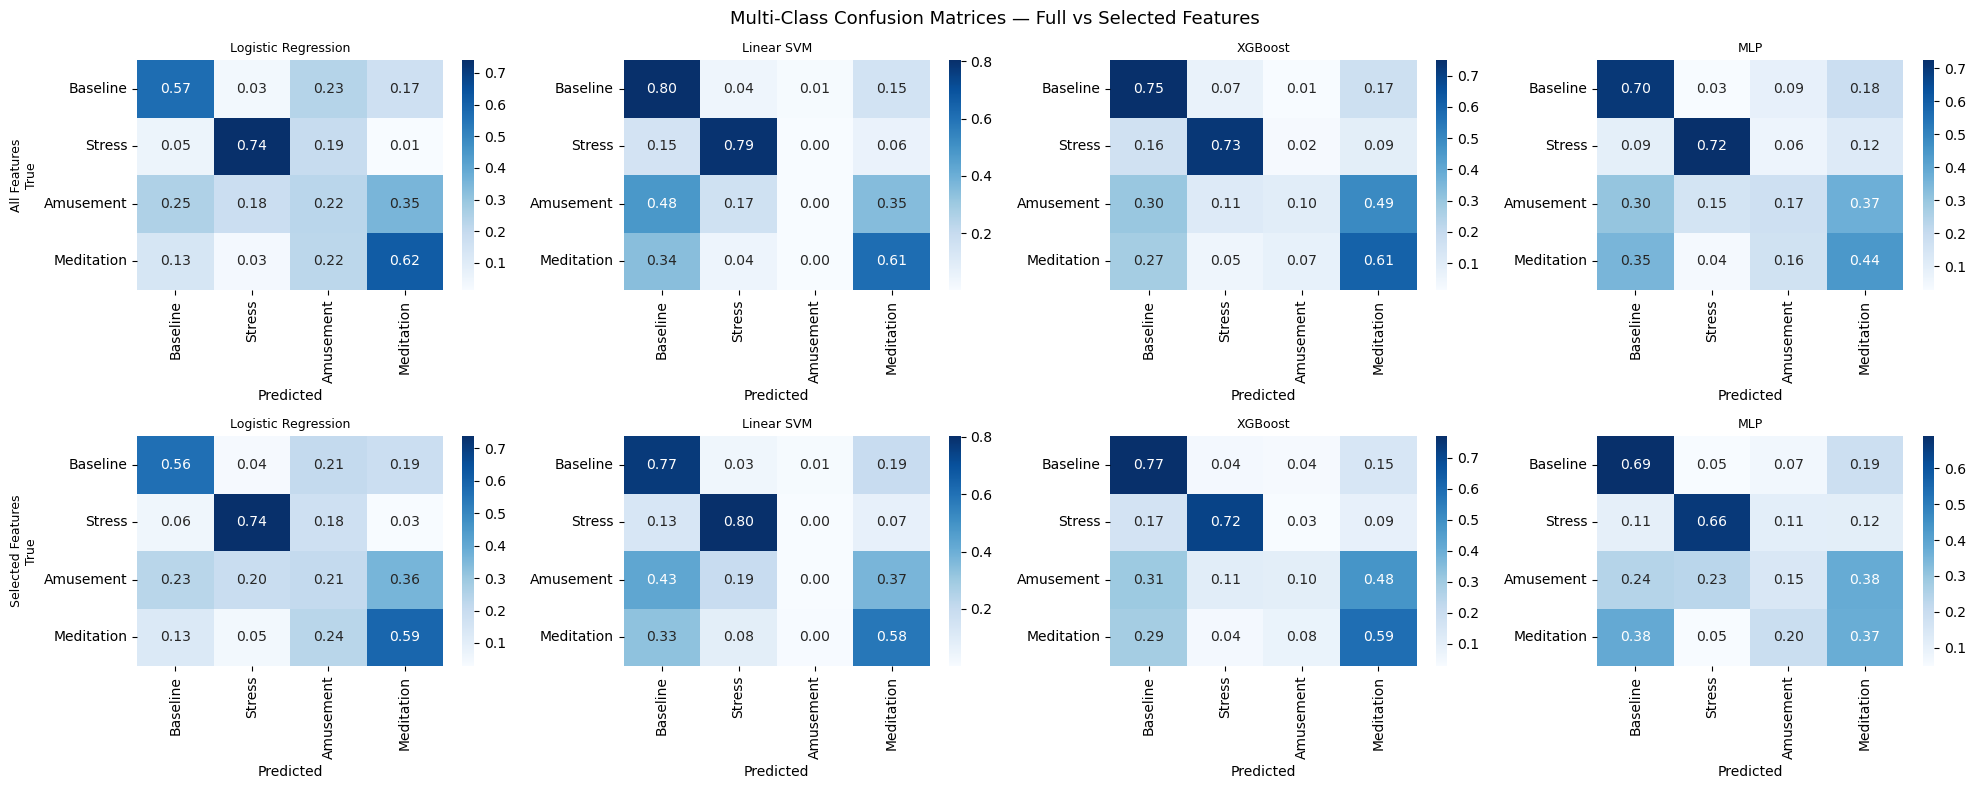

In [23]:
### 8.2 Confusion Matrices

fig, axes = plt.subplots(2, len(models), figsize=(5*len(models), 8))

for i, (model_name, payload) in enumerate(multiclass_results_full.items()):
    cm = np.array(payload['agg']['aggregated_cm'])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0, i])
    axes[0, i].set_title(f'{model_name}', fontsize=9)
    axes[0, i].set_xlabel('Predicted')

for i, (model_name, payload) in enumerate(multiclass_results_selected.items()):
    cm = np.array(payload['agg']['aggregated_cm'])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1, i])
    axes[1, i].set_title(f'{model_name}', fontsize=9)
    axes[1, i].set_xlabel('Predicted')

axes[0, 0].set_ylabel('All Features\nTrue', fontsize=9)
axes[1, 0].set_ylabel('Selected Features\nTrue', fontsize=9)
plt.suptitle('Multi-Class Confusion Matrices — Full vs Selected Features',
             fontsize=13)
plt.tight_layout()
plt.savefig('results_loso/figs/confusion_matrices_multiclass.png', dpi=140)
plt.show()

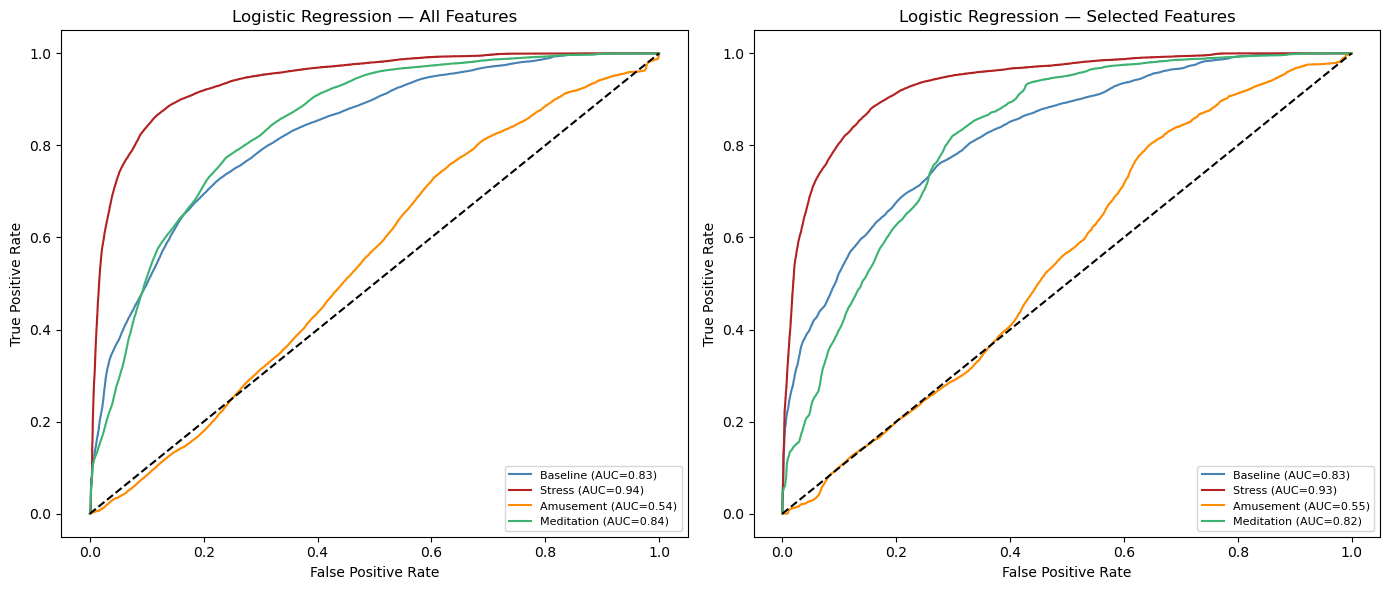

In [24]:
### 8.3 ROC Curves (Best Model — Full vs Selected Features)

from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_roc = ['steelblue', 'firebrick', 'darkorange', 'mediumseagreen']
best_model_name = best_multi['model']

for ax, (results_dict, title) in zip(axes, [
    (multiclass_results_full,     f'{best_model_name} — All Features'),
    (multiclass_results_selected, f'{best_model_name} — Selected Features'),
]):
    y_true_all, y_proba_all = [], []
    for subj_res in results_dict[best_model_name]['per_subject'].values():
        if subj_res['y_proba'] is None:
            y_proba_all = None
            break
        y_true_all.extend(subj_res['y_true'])
        y_proba_all.extend(subj_res['y_proba'])

    if y_proba_all is not None:
        y_true_all  = np.array(y_true_all)
        y_proba_all = np.array(y_proba_all)
        y_bin = label_binarize(y_true_all, classes=[1, 2, 3, 4])
        for i, (cls, col) in enumerate(zip(class_names, colors_roc)):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_all[:, i])
            ax.plot(fpr, tpr, color=col,
                    label=f"{cls} (AUC={auc(fpr, tpr):.2f})")

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('results_loso/figs/roc_curves_multiclass.png', dpi=140)
plt.show()

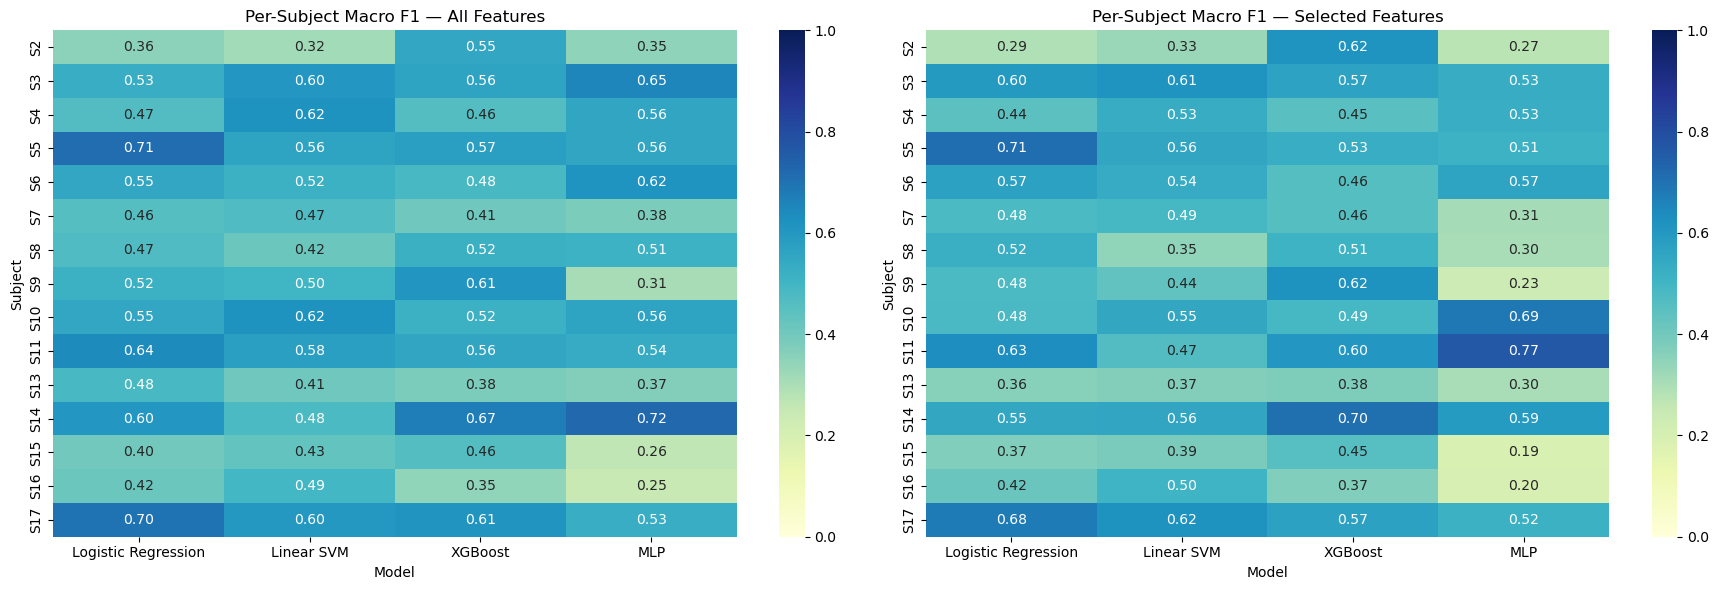

In [25]:
### 8.4 Per-Subject F1 Heatmaps (Full vs Selected Features)

subjects = sorted(
    multiclass_results_full[next(iter(multiclass_results_full))]['per_subject'].keys(),
    key=lambda s: int(s[1:])
)

heatmap_full = pd.DataFrame(index=subjects)
for model_name, payload in multiclass_results_full.items():
    heatmap_full[model_name] = [
        payload['per_subject'][s]['f1_macro'] for s in subjects]

heatmap_selected = pd.DataFrame(index=subjects)
for model_name, payload in multiclass_results_selected.items():
    heatmap_selected[model_name] = [
        payload['per_subject'][s]['f1_macro'] for s in subjects]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(heatmap_full, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Per-Subject Macro F1 — All Features')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Subject')

sns.heatmap(heatmap_selected, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Per-Subject Macro F1 — Selected Features')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Subject')

plt.tight_layout()
plt.savefig('results_loso/figs/per_subject_f1_heatmaps.png', dpi=140)
plt.show()

In [26]:
### 8.5 Comparison Against Paper Benchmark

benchmark = pd.DataFrame([
    {
        'Task': 'Multi-class',
        'Our Best Model': best_multi['model'],
        'Our Best Mean Accuracy': best_multi['mean_accuracy'],
        'Paper Best (Wrist)': 'RF/AB',
        'Paper Accuracy': 0.76
    }
])

print("Comparison to Schmidt et al. (2018):")
display(benchmark)

Comparison to Schmidt et al. (2018):


,Task,Our Best Model,Our Best Mean Accuracy,Paper Best (Wrist),Paper Accuracy
0,Multi-class,Logistic Regression,0.575699,RF/AB,0.76


## 9. Extensions

This section explores additional analyses that provide deeper insight into feature contributions, the difference between binary and multi-class difficulty, and inter-subject variability effects.

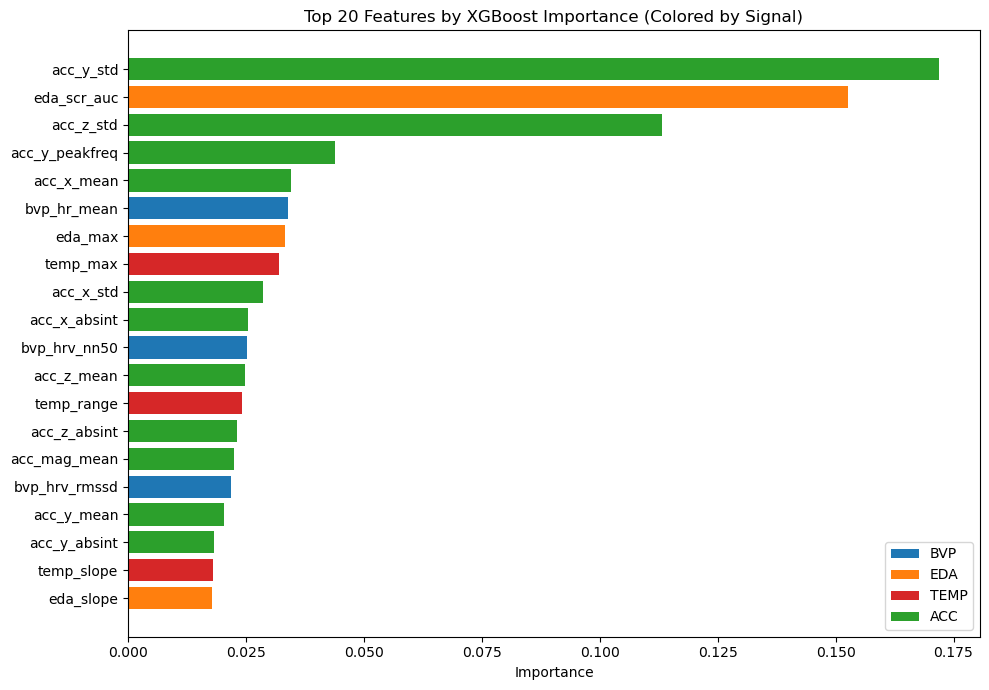

In [27]:
### 9.1 Feature Importance Analysis (Signal Groups)

signal_colors = {
    'BVP': 'tab:blue',
    'EDA': 'tab:orange',
    'TEMP': 'tab:red',
    'ACC': 'tab:green',
}

def infer_signal_group(feature_name):
    name = feature_name.lower()
    if name.startswith('bvp'):
        return 'BVP'
    if name.startswith('eda'):
        return 'EDA'
    if name.startswith('temp'):
        return 'TEMP'
    if name.startswith('acc'):
        return 'ACC'
    return 'OTHER'

top20 = importances.head(20)
feat_groups = [infer_signal_group(f) for f in top20.index]
colors = [signal_colors.get(g, 'tab:gray') for g in feat_groups]

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_title('Top 20 Features by XGBoost Importance (Colored by Signal)')
ax.set_xlabel('Importance')
legend_elements = [Patch(facecolor=c, label=k) for k, c in signal_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('results_loso/figs/feature_importance.png', dpi=140)
plt.show()

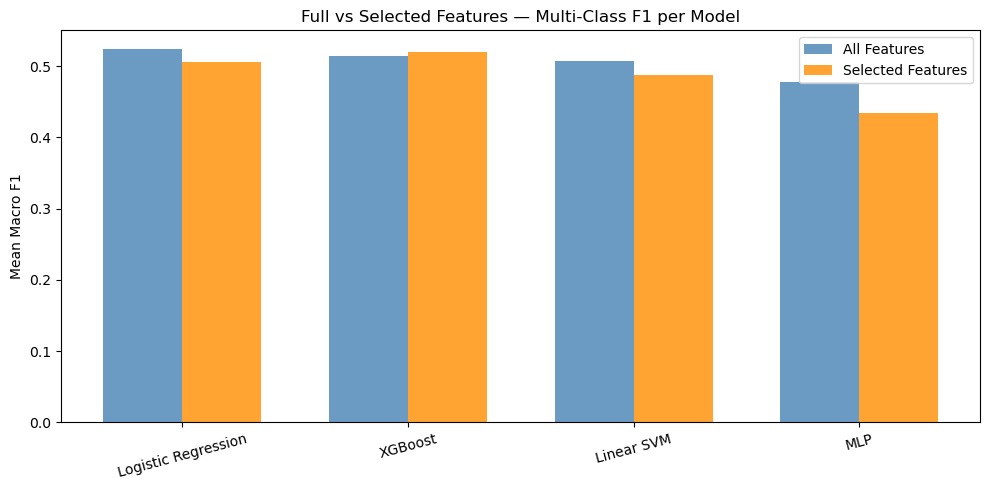


F1 delta (selected - full) per model:


,model,mean_f1_macro_full,mean_f1_macro_selected,f1_delta
0,Logistic Regression,0.524047,0.505889,-0.018159
1,XGBoost,0.514425,0.519204,0.004779
2,Linear SVM,0.507304,0.486911,-0.020393
3,MLP,0.477633,0.434403,-0.043230


In [28]:
### 9.2 Full vs Selected Features Comparison

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_multi))
width = 0.35
ax.bar(x - width/2, comp_multi['mean_f1_macro_full'],
       width, label='All Features', color='steelblue', alpha=0.8)
ax.bar(x + width/2, comp_multi['mean_f1_macro_selected'],
       width, label='Selected Features', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comp_multi['model'], rotation=15)
ax.set_ylabel('Mean Macro F1')
ax.set_title('Full vs Selected Features — Multi-Class F1 per Model')
ax.legend()
plt.tight_layout()
plt.savefig('results_loso/figs/full_vs_selected_f1.png', dpi=140)
plt.show()

print("\nF1 delta (selected - full) per model:")
display(comp_multi[['model', 'mean_f1_macro_full',
                     'mean_f1_macro_selected', 'f1_delta']])

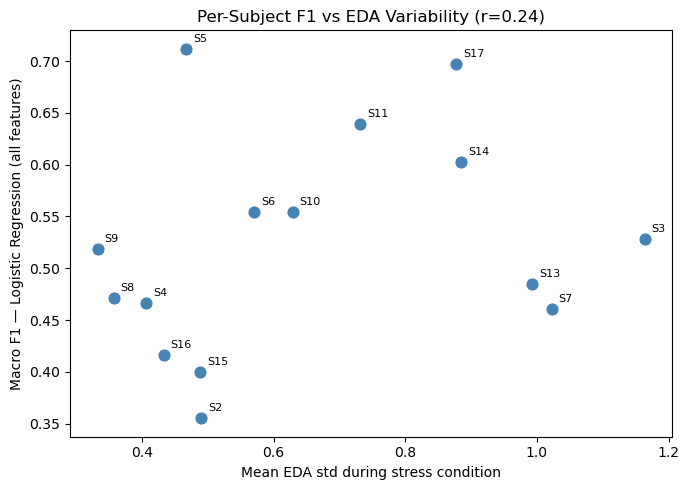

Pearson correlation: 0.244


In [29]:
### 9.3 Inter-Subject Variability vs Performance

best_model_name = best_multi['model']
subject_f1 = pd.Series(
    best_multi_results[best_model_name]['agg']['per_subject_f1']
)

eda_cols = [c for c in df.columns if 'eda' in c.lower()]
if len(eda_cols) == 0:
    print('No EDA columns found for variability analysis.')
else:
    df_stress = df[df['label'] == 2]
    eda_std_by_subject = df_stress.groupby('subject')[eda_cols].std().mean(axis=1)

    common_subjects = subject_f1.index.intersection(eda_std_by_subject.index)
    x_var = eda_std_by_subject.loc[common_subjects]
    y_var = subject_f1.loc[common_subjects]
    corr  = np.corrcoef(x_var, y_var)[0, 1]

    plt.figure(figsize=(7, 5))
    plt.scatter(x_var, y_var, color='steelblue', s=60)
    for subj in common_subjects:
        plt.annotate(subj, (x_var[subj], y_var[subj]),
                     textcoords='offset points', xytext=(5, 5), fontsize=8)
    plt.title(f'Per-Subject F1 vs EDA Variability (r={corr:.2f})')
    plt.xlabel('Mean EDA std during stress condition')
    plt.ylabel(f'Macro F1 — {best_model_name} ({best_fs_name})')
    plt.tight_layout()
    plt.savefig('results_loso/figs/f1_vs_eda_variability.png', dpi=140)
    plt.show()
    print(f"Pearson correlation: {corr:.3f}")